C:\Users\lenovo\AppData\Local\Temp\ipykernel_24768\3226108308.py:96: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_df.groupby(["Algorithm", "Condition"])["Value"]


Oringinal_and_augment
[[0.1619 0.1214 0.1207 0.119  0.1191 0.1176 0.1249 0.1614 0.12  ]
 [0.1422 0.114  0.1123 0.1083 0.113  0.108  0.1325 0.1582 0.1271]]


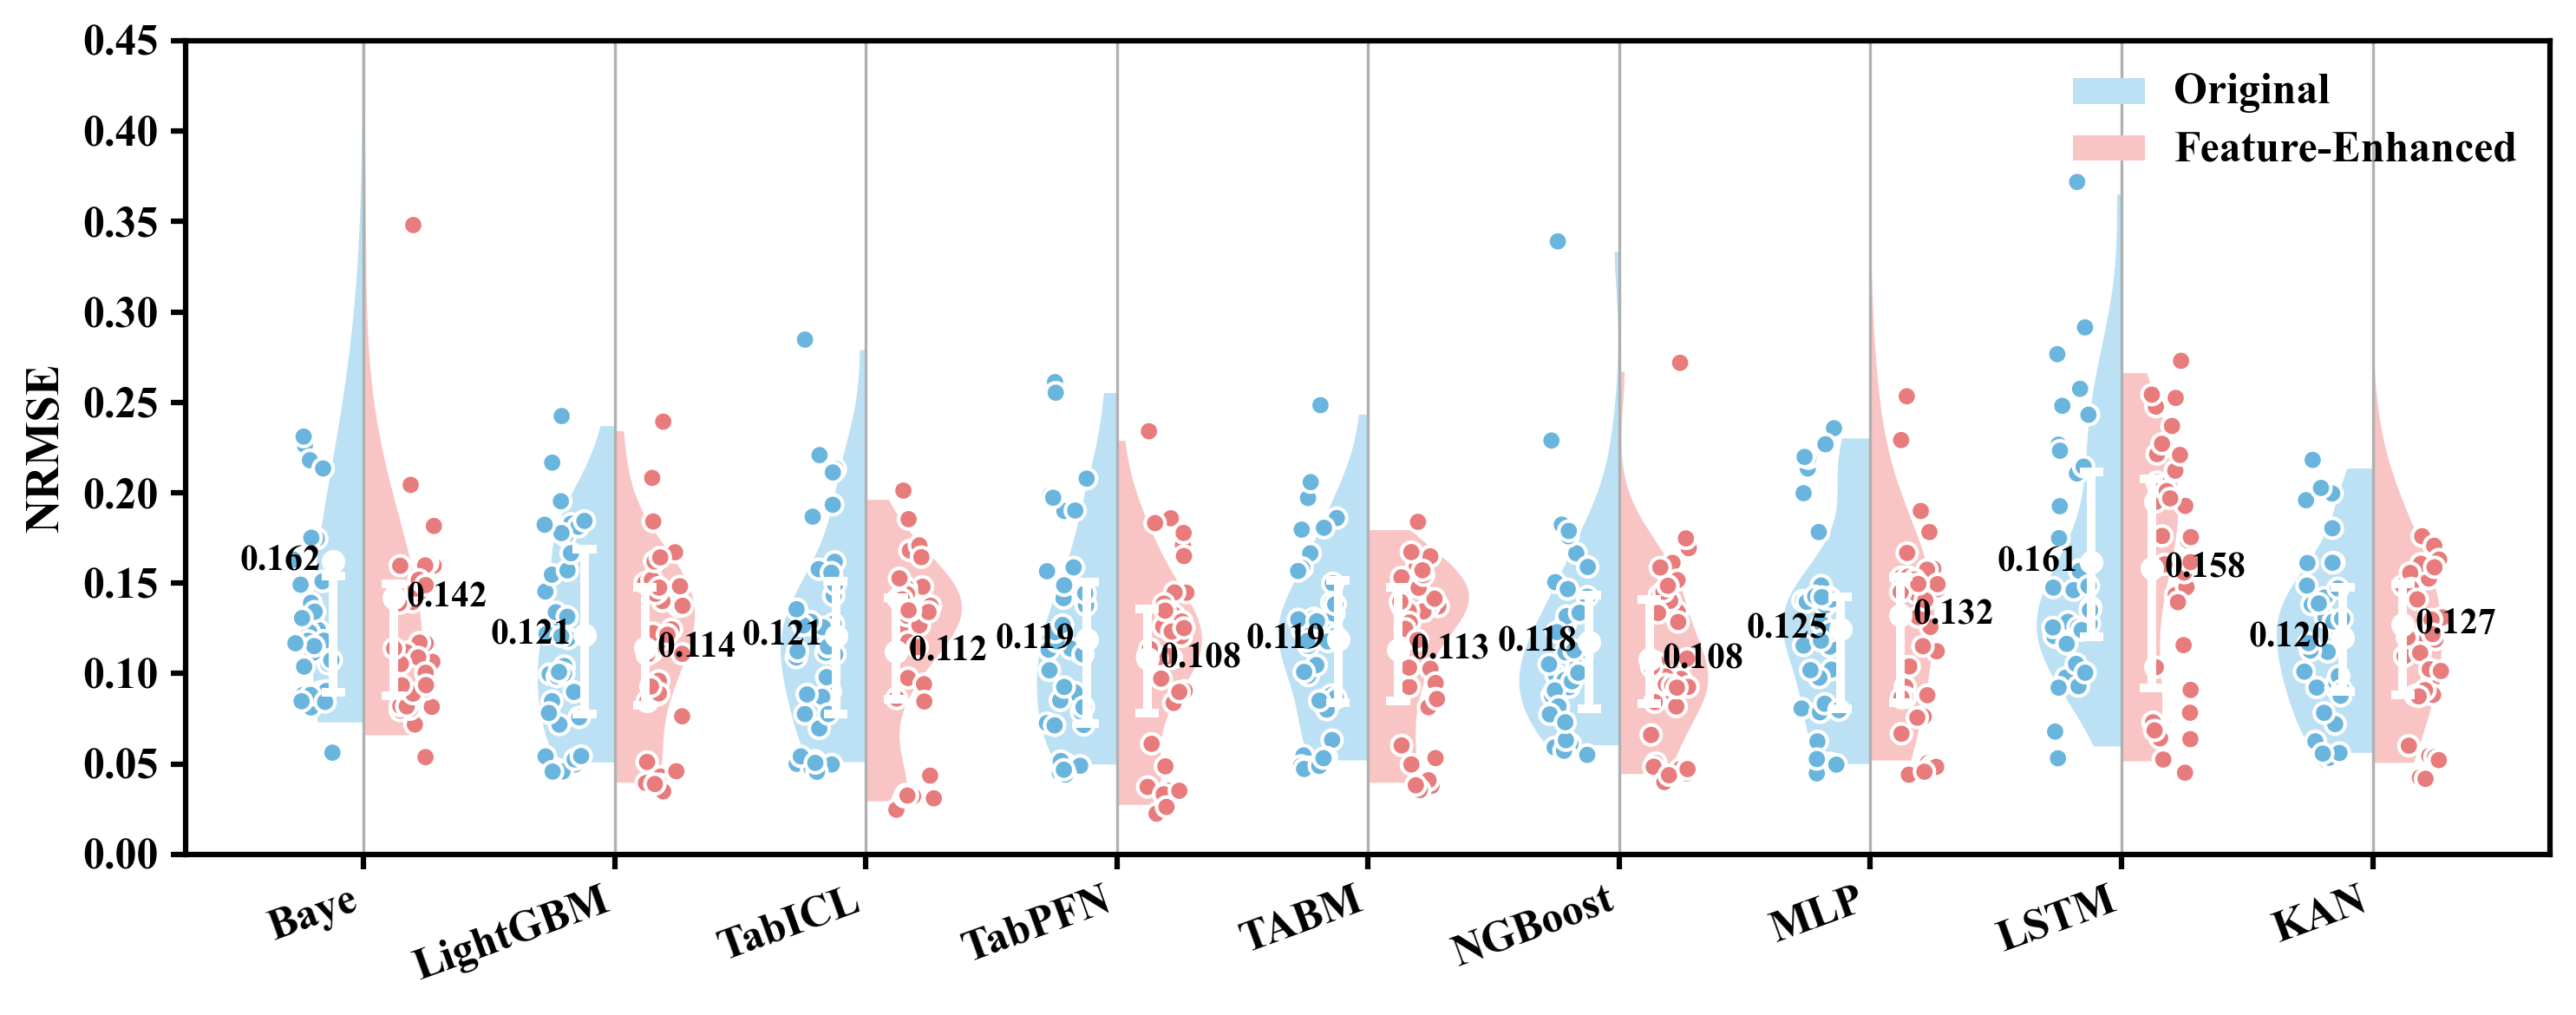

In [7]:

import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ==============================
# Global style settings
# ==============================
matplotlib.rcParams["pdf.fonttype"] = 42
matplotlib.rcParams["ps.fonttype"] = 42
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.weight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["axes.titleweight"] = "bold"

# ==============================
# User settings
# ==============================
Original_FILE = "testday_30_noagu_predict_result1.xlsx"
Feature_Enhanced_FILE = "testday_30_agument_predict_result1.xlsx"   # Replace with your "Feature-Enhanced feature enhancement" file
METRIC_NAME = "NRMSE"   # Change to "CWC" or "IS" when needed
OUTPUT_DIR = r"figure_plot"
OUTPUT_NAME = f"bean_chart_{METRIC_NAME.lower()}"

PALETTE_VIOLIN = {
    "Feature-Enhanced": "#F9C4C4",
    "Original": "#BCE0F4",
}
PALETTE_SCATTER = {
    "Feature-Enhanced": "#E87C7C",
    "Original": "#6AB5DE",
}

# ==============================
# Helper functions
# ==============================
def get_metric_column_range(raw_df: pd.DataFrame, metric_name: str):
    """
    Find the start and end columns for a target metric block.
    The first row stores metric names, and the second row stores algorithm names.
    """
    metric_row = raw_df.iloc[0, :]
    metric_positions = [i for i, value in enumerate(metric_row) if str(value).strip() == metric_name]
    if not metric_positions:
        raise ValueError(f"Metric '{metric_name}' was not found in the first header row.")

    start_col = metric_positions[0]
    end_col = raw_df.shape[1] - 1

    for col in range(start_col + 1, raw_df.shape[1]):
        cell_value = raw_df.iat[0, col]
        if pd.notna(cell_value) and str(cell_value).strip() != "":
            end_col = col - 1
            break

    return start_col, end_col


def extract_metric_long_table(file_path: str, metric_name: str, condition_name: str):
    """
    Read one Excel file and convert the selected metric block to a long-format table.
    Expected file format:
    - Row 0: metric names
    - Row 1: algorithm names
    - Row 2: blank row
    - Remaining rows: station-level records
    """
    raw_df = pd.read_excel(file_path, header=None)

    start_col, end_col = get_metric_column_range(raw_df, metric_name)
    algorithm_names = raw_df.iloc[1, start_col:end_col + 1].tolist()

    station_mask = raw_df.iloc[:, 0].astype(str).str.startswith("PV_")
    data_df = raw_df.loc[station_mask, [0] + list(range(start_col, end_col + 1))].copy()
    data_df.columns = ["Station"] + algorithm_names

    long_df = data_df.melt(
        id_vars="Station",
        var_name="Algorithm",
        value_name="Value"
    )
    long_df["Value"] = pd.to_numeric(long_df["Value"], errors="coerce")
    long_df["Condition"] = condition_name
    long_df = long_df.dropna(subset=["Value"]).reset_index(drop=True)

    return long_df, algorithm_names

def add_summary_lines_and_text(ax, plot_df, algorithm_order, condition_order):
    """
    Draw the white IQR lines, mean points, and mean value labels on each side.
    """
    stats_df = (
        plot_df.groupby(["Algorithm", "Condition"])["Value"]
        .agg(
            mean="mean",
            q1=lambda x: np.percentile(x, 25),
            q3=lambda x: np.percentile(x, 75),
        )
        .reset_index()
    )

    offset_map = {"Original": -0.12, "Feature-Enhanced": 0.12}
    text_offset_map = {"Original": -0.05, "Feature-Enhanced": 0.05}
    cap_width = 0.03

    mean_lsit=[]
    for i, algorithm in enumerate(algorithm_order):
        for condition in condition_order:
            row = stats_df[
                (stats_df["Algorithm"] == algorithm) &
                (stats_df["Condition"] == condition)
            ].iloc[0]

            mean_val = row["mean"]
            q1_val = row["q1"]
            q3_val = row["q3"]
            mean_lsit.append(mean_val)
            x_pos = i + offset_map[condition]

            ax.plot([x_pos, x_pos], [q1_val, q3_val], color="white", lw=2.4, zorder=3)
            ax.plot([x_pos - cap_width, x_pos + cap_width], [q1_val, q1_val], color="white", lw=2.4, zorder=3)
            ax.plot([x_pos - cap_width, x_pos + cap_width], [q3_val, q3_val], color="white", lw=2.4, zorder=3)
            ax.plot(x_pos, mean_val, marker="o", color="white", markersize=5.5, zorder=4)

            ha = "right" if condition == "Original" else "left"
            ax.text(
                x_pos + text_offset_map[condition],
                mean_val,
                f"{mean_val:.3f}",
                ha=ha,
                va="center",
                fontsize=10,
                fontweight="bold",
                color="black",
                zorder=5
            )
    # print(mean_lsit)
    before_list = mean_lsit[0::2]

    # Extract after-enhancement values: index 1, 3, 5, ...
    after_list = mean_lsit[1::2]

    # Arrange into two rows and keep 4 decimal places
    mean_array = np.array([
        [round(x, 4) for x in before_list],
        [round(x, 4) for x in after_list]])
    print('Oringinal_and_augment')
    print(mean_array)


def plot_bean_chart(plot_df: pd.DataFrame, metric_name: str, output_dir: str, output_name: str):
    """
    Plot the split bean chart for one metric.
    """
    os.makedirs(output_dir, exist_ok=True)

    algorithm_order = plot_df["Algorithm"].drop_duplicates().tolist()
    condition_order = ["Original", "Feature-Enhanced"]

    fig, ax = plt.subplots(figsize=(10, 4), dpi=300)

    sns.violinplot(
        data=plot_df,
        x="Algorithm",
        y="Value",
        hue="Condition",
        hue_order=condition_order,
        split=True,
        inner=None,
        palette=PALETTE_VIOLIN,
        linewidth=0,
        cut=-0.2,
        saturation=1,
        ax=ax
    )

    sns.stripplot(
        data=plot_df,
        x="Algorithm",
        y="Value",
        hue="Condition",
        dodge=True,
        palette=PALETTE_SCATTER,
        alpha=1.0,
        size=5.5,
        jitter=0.16,
        zorder=2,
        order=algorithm_order,
        hue_order=condition_order,
        edgecolor="white",
        linewidth=1.0,
        ax=ax
    )

    add_summary_lines_and_text(ax, plot_df, algorithm_order, condition_order)
#   add_significance_labels(ax, plot_df, algorithm_order)


    handles, labels = ax.get_legend_handles_labels()
    legend = ax.legend(
            handles[:2],
            labels[:2],
            title="",
            loc="upper right",
            frameon=False)
    plt.setp(legend.get_texts(), fontweight="bold", fontsize=12)

    y_min = plot_df["Value"].min()
    y_max = plot_df["Value"].max()
    y_range = y_max - y_min
#     ax.set_ylim(y_min - 0.08 * y_range, y_max + 0.20 * y_range)
    ax.set_ylim(0, 0.45)

#     ax.set_title(f"{metric_name} Comparison Original and Feature-Enhanced Feature Enhancement", fontsize=16, fontweight="bold", pad=14)
    ax.set_xlabel("")
    ax.set_ylabel(metric_name, fontsize=13, fontweight="bold")

    ax.tick_params(
        axis="both",
        which="major",
        direction="out",
        length=4,
        width=1.5,
        labelsize=12
    )

    for tick in ax.get_xticklabels():
        tick.set_rotation(20)
        tick.set_ha("right")
        tick.set_fontweight("bold")

    for tick in ax.get_yticklabels():
        tick.set_fontweight("bold")

    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
        spine.set_color("black")

#     ax.grid(True)
    ax.xaxis.grid(True)
    ax.yaxis.grid(False)
    plt.tight_layout()

    png_path = os.path.join(output_dir, f"{output_name}.png")
    pdf_path = os.path.join(output_dir, f"{output_name}.pdf")
    plt.savefig(png_path, dpi=300, bbox_inches="tight")
    plt.savefig(pdf_path, bbox_inches="tight")
    plt.show()


# ==============================
# Main execution
# ==============================
if __name__ == "__main__":
    Original_long, algorithm_order_Original = extract_metric_long_table(
        file_path=Original_FILE,
        metric_name=METRIC_NAME,
        condition_name="Original"
    )

    Feature_Enhanced_long, algorithm_order_Feature_Enhanced = extract_metric_long_table(
        file_path=Feature_Enhanced_FILE,
        metric_name=METRIC_NAME,
        condition_name="Feature-Enhanced"
    )

#     if algorithm_order_Original != algorithm_order_after:
#         raise ValueError("The algorithm order in the two files is inconsistent.")

    plot_df = pd.concat([Original_long, Feature_Enhanced_long], ignore_index=True)

    plot_df["Algorithm"] = pd.Categorical(
        plot_df["Algorithm"],
        categories=algorithm_order_Original,
        ordered=True
    )

    plot_df["Condition"] = pd.Categorical(
        plot_df["Condition"],
        categories=["Original", "Feature-Enhanced"],
        ordered=True
    )

    plot_df = plot_df.sort_values(["Algorithm", "Condition", "Station"]).reset_index(drop=True)
    
    plot_bean_chart(
        plot_df=plot_df,
        metric_name=METRIC_NAME,
        output_dir=OUTPUT_DIR,
        output_name=OUTPUT_NAME
    )


C:\Users\lenovo\AppData\Local\Temp\ipykernel_24768\959648665.py:110: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_df.groupby(["Algorithm", "Condition"])["Value"]


Oringinal_and_augment
[[2.3376 3.0987 0.2375 0.2399 0.2998 0.5747 0.347  0.5546 0.2891]
 [1.6815 2.5664 0.1889 0.1722 0.232  0.3081 0.4859 0.6947 0.431 ]]


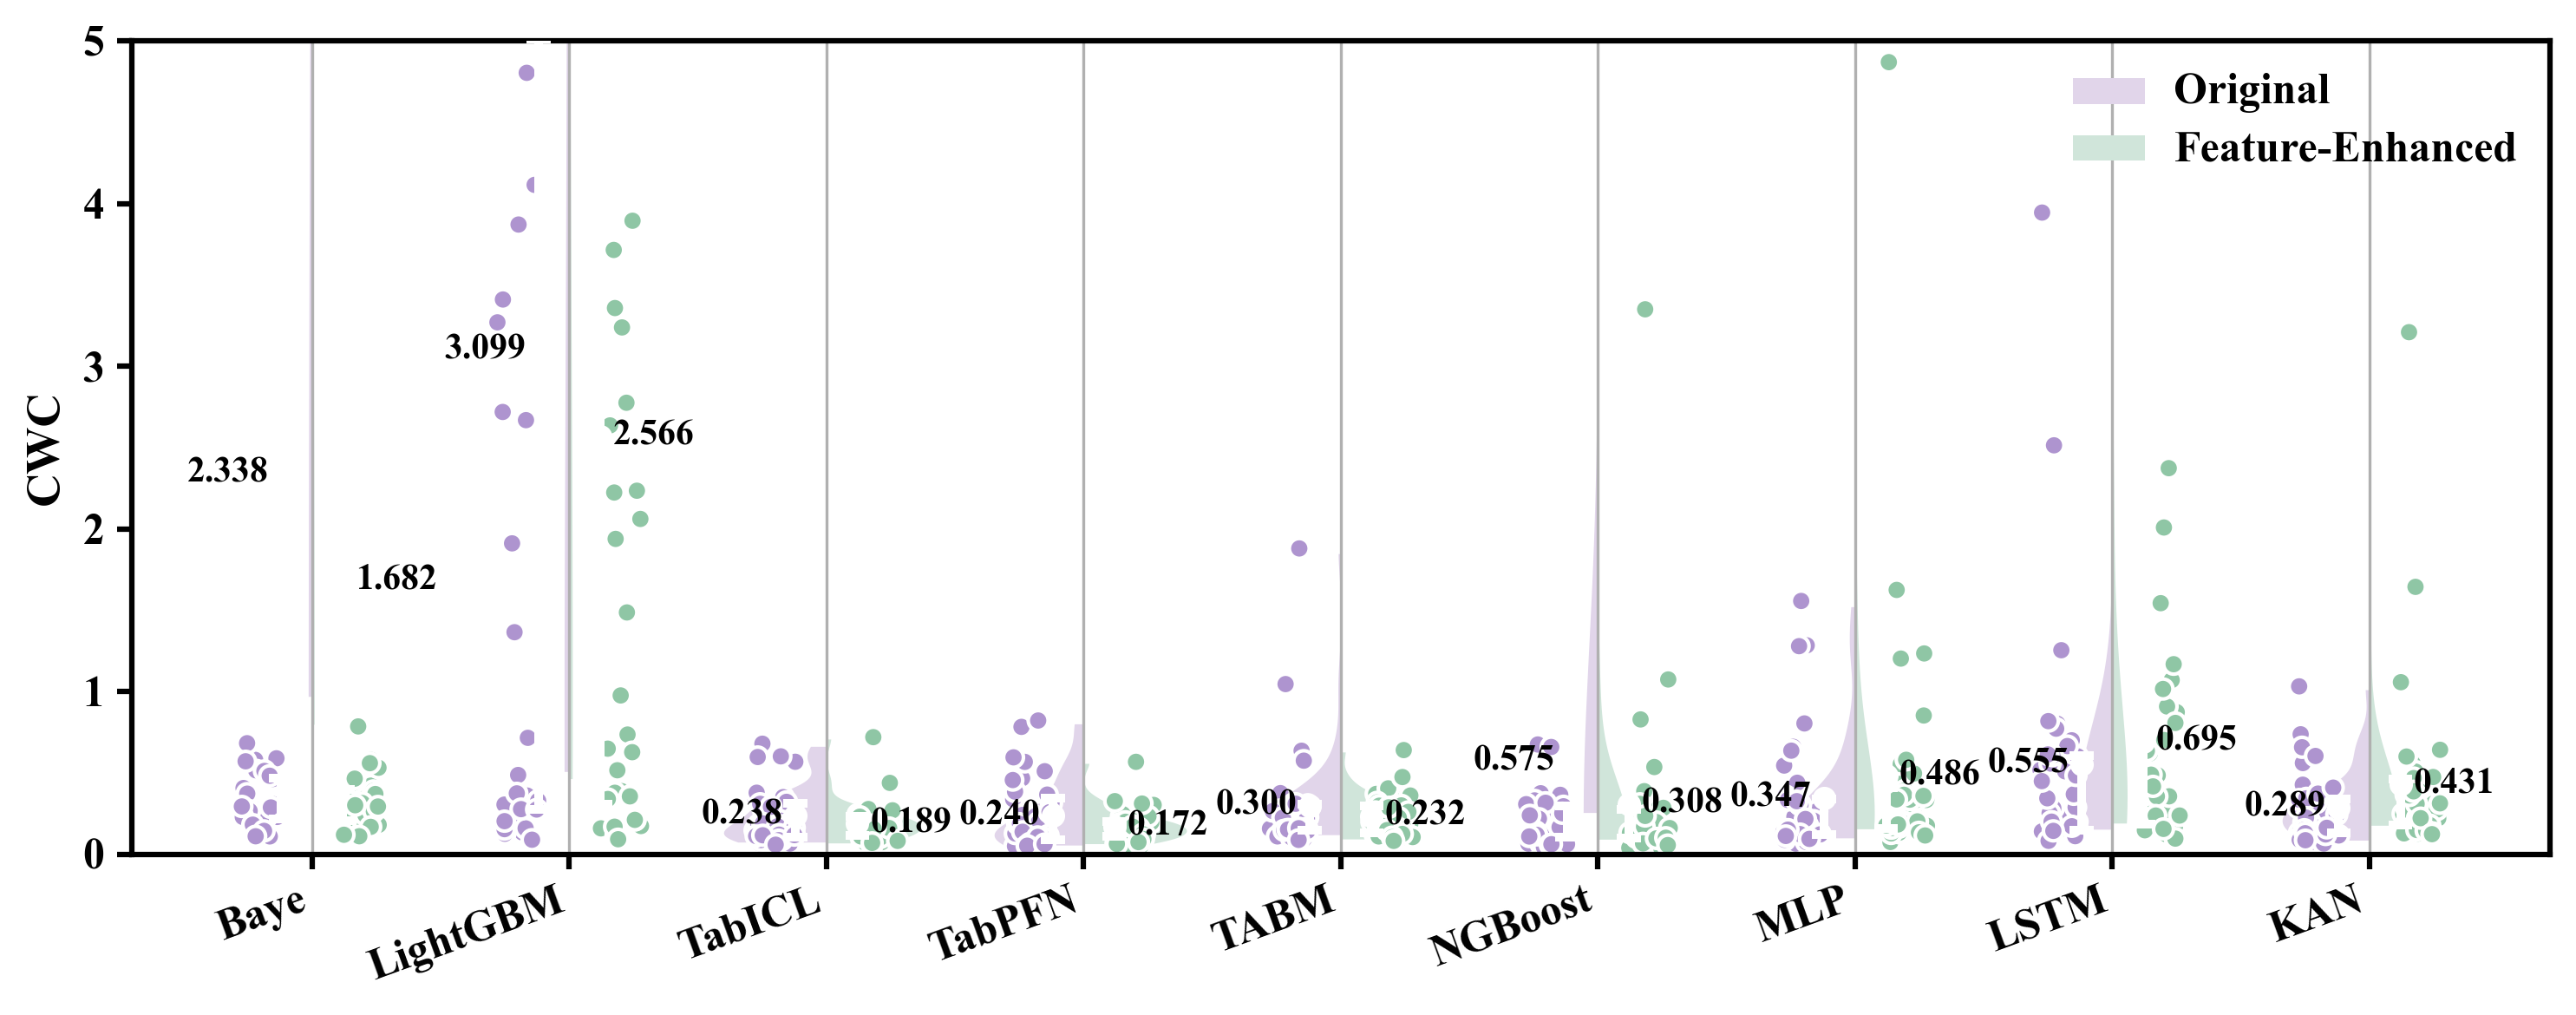

In [ ]:

import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ==============================
# Global style settings
# ==============================
matplotlib.rcParams["pdf.fonttype"] = 42
matplotlib.rcParams["ps.fonttype"] = 42
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.weight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["axes.titleweight"] = "bold"

# ==============================
# User settings
# ==============================
Original_FILE = "testday_30_noagu_predict_result1.xlsx"
Feature_Enhanced_FILE = "testday_30_agument_predict_result1.xlsx"   # Replace with your "Feature-Enhanced feature enhancement" file
METRIC_NAME = "CWC"   # Change to "CWC" or "IS" when needed
OUTPUT_DIR = r"figure_plot"
OUTPUT_NAME = f"bean_chart_{METRIC_NAME.lower()}"

PALETTE_VIOLIN = {
    "Feature-Enhanced": "#D0E5DA",
    "Original": "#E1D5EA",
}
PALETTE_SCATTER = {
    "Feature-Enhanced": "#8FC6A5",
    "Original": "#AE94CF",
}

# ==============================
# Helper functions
# ==============================
def get_metric_column_range(raw_df: pd.DataFrame, metric_name: str):
    """
    Find the start and end columns for a target metric block.
    The first row stores metric names, and the second row stores algorithm names.
    """
    metric_row = raw_df.iloc[0, :]
    metric_positions = [i for i, value in enumerate(metric_row) if str(value).strip() == metric_name]
    if not metric_positions:
        raise ValueError(f"Metric '{metric_name}' was not found in the first header row.")

    start_col = metric_positions[0]
    end_col = raw_df.shape[1] - 1

    for col in range(start_col + 1, raw_df.shape[1]):
        cell_value = raw_df.iat[0, col]
        if pd.notna(cell_value) and str(cell_value).strip() != "":
            end_col = col - 1
            break

    return start_col, end_col


def extract_metric_long_table(file_path: str, metric_name: str, condition_name: str):
    """
    Read one Excel file and convert the selected metric block to a long-format table.
    Expected file format:
    - Row 0: metric names
    - Row 1: algorithm names
    - Row 2: blank row
    - Remaining rows: station-level records
    """
    raw_df = pd.read_excel(file_path, header=None)

    start_col, end_col = get_metric_column_range(raw_df, metric_name)
    algorithm_names = raw_df.iloc[1, start_col:end_col + 1].tolist()

    station_mask = raw_df.iloc[:, 0].astype(str).str.startswith("PV_")
    data_df = raw_df.loc[station_mask, [0] + list(range(start_col, end_col + 1))].copy()
    data_df.columns = ["Station"] + algorithm_names

    long_df = data_df.melt(
        id_vars="Station",
        var_name="Algorithm",
        value_name="Value"
    )
    long_df["Value"] = pd.to_numeric(long_df["Value"], errors="coerce")
    long_df["Condition"] = condition_name
    long_df = long_df.dropna(subset=["Value"]).reset_index(drop=True)

    return long_df, algorithm_names


def add_summary_lines_and_text(ax, plot_df, algorithm_order, condition_order):
    """
    Draw the white IQR lines, mean points, and mean value labels on each side.
    """
    stats_df = (
        plot_df.groupby(["Algorithm", "Condition"])["Value"]
        .agg(
            mean="mean",
            q1=lambda x: np.percentile(x, 25),
            q3=lambda x: np.percentile(x, 75),
        )
        .reset_index()
    )

    offset_map = {"Original": -0.12, "Feature-Enhanced": 0.12}
    text_offset_map = {"Original": -0.05, "Feature-Enhanced": 0.05}
    cap_width = 0.03
    mean_lsit=[]
    for i, algorithm in enumerate(algorithm_order):
        for condition in condition_order:
            row = stats_df[
                (stats_df["Algorithm"] == algorithm) &
                (stats_df["Condition"] == condition)
            ].iloc[0]

            mean_val = row["mean"]
            q1_val = row["q1"]
            q3_val = row["q3"]
            mean_lsit.append(mean_val)
            x_pos = i + offset_map[condition]

            ax.plot([x_pos, x_pos], [q1_val, q3_val], color="white", lw=2.4, zorder=3)
            ax.plot([x_pos - cap_width, x_pos + cap_width], [q1_val, q1_val], color="white", lw=2.4, zorder=3)
            ax.plot([x_pos - cap_width, x_pos + cap_width], [q3_val, q3_val], color="white", lw=2.4, zorder=3)
            ax.plot(x_pos, mean_val, marker="o", color="white", markersize=5.5, zorder=4)

            ha = "right" if condition == "Original" else "left"
            ax.text(
                x_pos + text_offset_map[condition],
                mean_val,
                f"{mean_val:.3f}",
                ha=ha,
                va="center",
                fontsize=10,
                fontweight="bold",
                color="black",
                zorder=5
            )
    # print(mean_lsit)
    before_list = mean_lsit[0::2]

    # Extract after-enhancement values: index 1, 3, 5, ...
    after_list = mean_lsit[1::2]

    # Arrange into two rows and keep 4 decimal places
    mean_array = np.array([
        [round(x, 4) for x in before_list],
        [round(x, 4) for x in after_list]])
    print('Oringinal_and_augment')
    print(mean_array)



def plot_bean_chart(plot_df: pd.DataFrame, metric_name: str, output_dir: str, output_name: str):
    """
    Plot the split bean chart for one metric.
    """
    os.makedirs(output_dir, exist_ok=True)

    algorithm_order = plot_df["Algorithm"].drop_duplicates().tolist()
    condition_order = ["Original", "Feature-Enhanced"]

    fig, ax = plt.subplots(figsize=(10, 4), dpi=300)

    sns.violinplot(
        data=plot_df,
        x="Algorithm",
        y="Value",
        hue="Condition",
        hue_order=condition_order,
        split=True,
        inner=None,
        palette=PALETTE_VIOLIN,
        linewidth=0,
        cut=-0.2,
        saturation=1,
        ax=ax
    )

    sns.stripplot(
        data=plot_df,
        x="Algorithm",
        y="Value",
        hue="Condition",
        dodge=True,
        palette=PALETTE_SCATTER,
        alpha=1.0,
        size=5.5,
        jitter=0.16,
        zorder=2,
        order=algorithm_order,
        hue_order=condition_order,
        edgecolor="white",
        linewidth=1.0,
        ax=ax
    )

    add_summary_lines_and_text(ax, plot_df, algorithm_order, condition_order)
#   add_significance_labels(ax, plot_df, algorithm_order)


    handles, labels = ax.get_legend_handles_labels()
    legend = ax.legend(
            handles[:2],
            labels[:2],
            title="",
            loc="upper right",
            frameon=False)
    plt.setp(legend.get_texts(), fontweight="bold", fontsize=12)

    y_min = plot_df["Value"].min()
    y_max = plot_df["Value"].max()
    y_range = y_max - y_min
#     ax.set_ylim(y_min - 0.08 * y_range, y_max + 0.20 * y_range)
    ax.set_ylim(0, 5)

#     ax.set_title(f"{metric_name} Comparison Original and Feature-Enhanced Feature Enhancement", fontsize=16, fontweight="bold", pad=14)
    ax.set_xlabel("")
    ax.set_ylabel(metric_name, fontsize=13, fontweight="bold")

    ax.tick_params(
        axis="both",
        which="major",
        direction="out",
        length=4,
        width=1.5,
        labelsize=12
    )

    for tick in ax.get_xticklabels():
        tick.set_rotation(20)
        tick.set_ha("right")
        tick.set_fontweight("bold")

    for tick in ax.get_yticklabels():
        tick.set_fontweight("bold")

    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
        spine.set_color("black")

#     ax.grid(True)
    ax.xaxis.grid(True)
    ax.yaxis.grid(False)
    plt.tight_layout()

    png_path = os.path.join(output_dir, f"{output_name}.png")
    pdf_path = os.path.join(output_dir, f"{output_name}.pdf")
    plt.savefig(png_path, dpi=300, bbox_inches="tight")
    plt.savefig(pdf_path, bbox_inches="tight")
    plt.show()


# ==============================
# Main execution
# ==============================
if __name__ == "__main__":
    Original_long, algorithm_order_Original = extract_metric_long_table(
        file_path=Original_FILE,
        metric_name=METRIC_NAME,
        condition_name="Original"
    )

    Feature_Enhanced_long, algorithm_order_Feature_Enhanced = extract_metric_long_table(
        file_path=Feature_Enhanced_FILE,
        metric_name=METRIC_NAME,
        condition_name="Feature-Enhanced"
    )

#     if algorithm_order_Original != algorithm_order_after:
#         raise ValueError("The algorithm order in the two files is inconsistent.")

    plot_df = pd.concat([Original_long, Feature_Enhanced_long], ignore_index=True)

    plot_df["Algorithm"] = pd.Categorical(
        plot_df["Algorithm"],
        categories=algorithm_order_Original,
        ordered=True
    )

    plot_df["Condition"] = pd.Categorical(
        plot_df["Condition"],
        categories=["Original", "Feature-Enhanced"],
        ordered=True
    )

    plot_df = plot_df.sort_values(["Algorithm", "Condition", "Station"]).reset_index(drop=True)
    
    plot_bean_chart(
        plot_df=plot_df,
        metric_name=METRIC_NAME,
        output_dir=OUTPUT_DIR,
        output_name=OUTPUT_NAME
    )


C:\Users\lenovo\AppData\Local\Temp\ipykernel_24768\1614268838.py:118: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_df.groupby(["Algorithm", "Condition"])["Value"]


Oringinal_and_augment
[[0.1158 0.1085 0.1103 0.1072 0.0999 0.11   0.0998 0.1082 0.1052]
 [0.1144 0.1042 0.1026 0.1045 0.0952 0.1037 0.1026 0.1136 0.1052]]


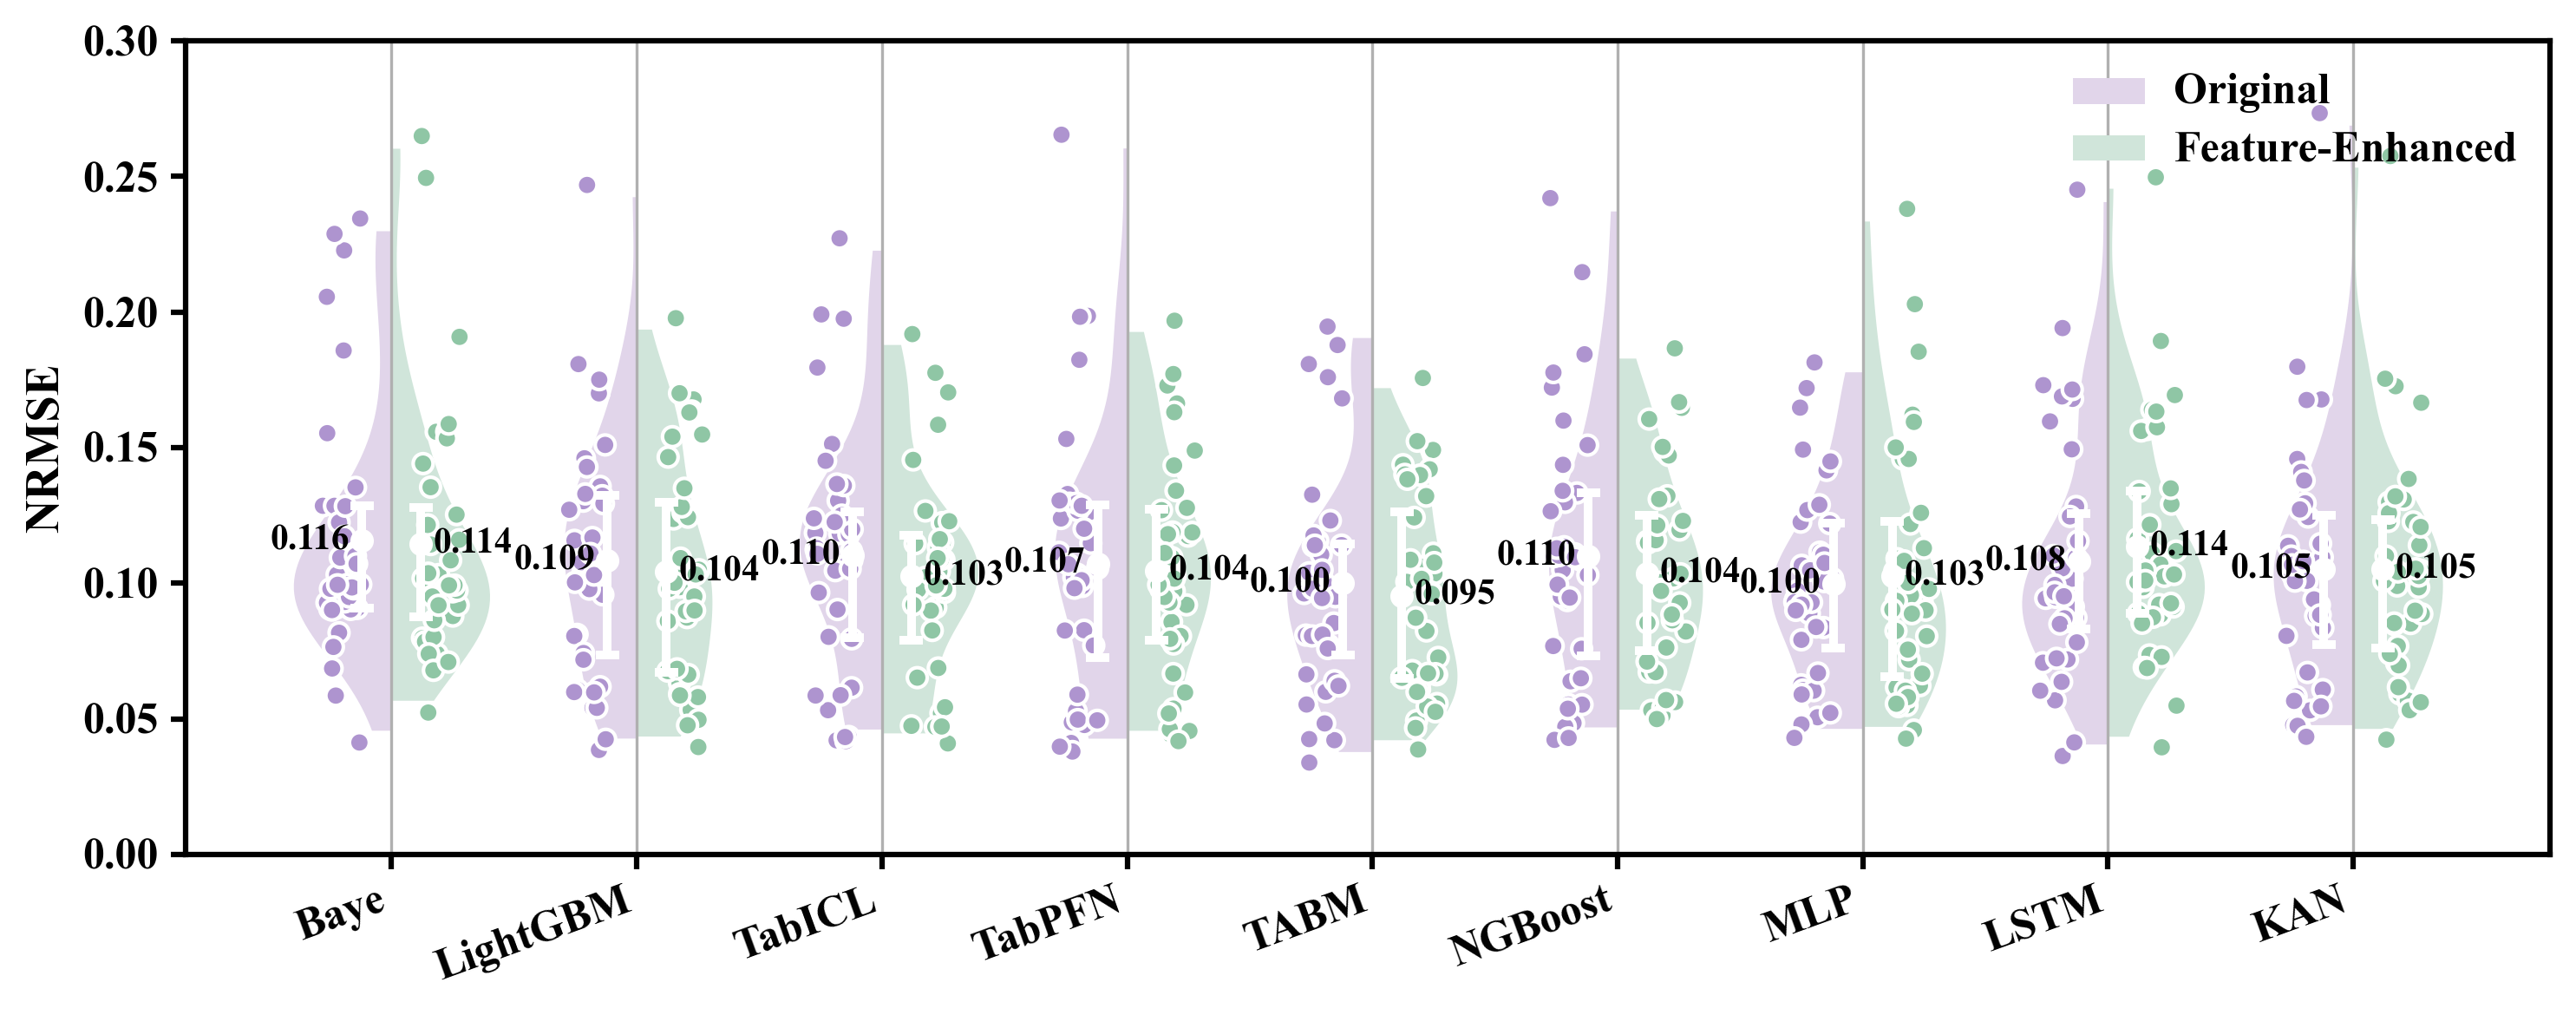

In [ ]:

import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ==============================
# Global style settings
# ==============================
matplotlib.rcParams["pdf.fonttype"] = 42
matplotlib.rcParams["ps.fonttype"] = 42
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.weight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["axes.titleweight"] = "bold"

# ==============================
# User settings
# ==============================
Original_FILE = "testday_100_noagu_predict_result1.xlsx"
Feature_Enhanced_FILE = "testday_100_agument_predict_result1.xlsx"   # Replace with your "Feature-Enhanced feature enhancement" file
METRIC_NAME = "NRMSE"   # Change to "CWC" or "IS" when needed
OUTPUT_DIR = r"figure_plot"
OUTPUT_NAME = f"100_day_test_bean_chart_{METRIC_NAME.lower()}"

PALETTE_VIOLIN = {
    "Feature-Enhanced": "#D0E5DA",
    "Original": "#E1D5EA",
}
PALETTE_SCATTER = {
    "Feature-Enhanced": "#8FC6A5",
    "Original": "#AE94CF",
}
# PALETTE_VIOLIN = {
#     "Feature-Enhanced": "#F9C4C4",
#     "Original": "#BCE0F4",
# }
# PALETTE_SCATTER = {
#     "Feature-Enhanced": "#E87C7C",
#     "Original": "#6AB5DE",
# }

# ==============================
# Helper functions
# ==============================
def get_metric_column_range(raw_df: pd.DataFrame, metric_name: str):
    """
    Find the start and end columns for a target metric block.
    The first row stores metric names, and the second row stores algorithm names.
    """
    metric_row = raw_df.iloc[0, :]
    metric_positions = [i for i, value in enumerate(metric_row) if str(value).strip() == metric_name]
    if not metric_positions:
        raise ValueError(f"Metric '{metric_name}' was not found in the first header row.")

    start_col = metric_positions[0]
    end_col = raw_df.shape[1] - 1

    for col in range(start_col + 1, raw_df.shape[1]):
        cell_value = raw_df.iat[0, col]
        if pd.notna(cell_value) and str(cell_value).strip() != "":
            end_col = col - 1
            break

    return start_col, end_col


def extract_metric_long_table(file_path: str, metric_name: str, condition_name: str):
    """
    Read one Excel file and convert the selected metric block to a long-format table.
    Expected file format:
    - Row 0: metric names
    - Row 1: algorithm names
    - Row 2: blank row
    - Remaining rows: station-level records
    """
    raw_df = pd.read_excel(file_path, header=None)

    start_col, end_col = get_metric_column_range(raw_df, metric_name)
    algorithm_names = raw_df.iloc[1, start_col:end_col + 1].tolist()

    station_mask = raw_df.iloc[:, 0].astype(str).str.startswith("PV_")
    data_df = raw_df.loc[station_mask, [0] + list(range(start_col, end_col + 1))].copy()
    data_df.columns = ["Station"] + algorithm_names

    long_df = data_df.melt(
        id_vars="Station",
        var_name="Algorithm",
        value_name="Value"
    )
    long_df["Value"] = pd.to_numeric(long_df["Value"], errors="coerce")
    long_df["Condition"] = condition_name
    long_df = long_df.dropna(subset=["Value"]).reset_index(drop=True)

    return long_df, algorithm_names


def add_summary_lines_and_text(ax, plot_df, algorithm_order, condition_order):
    """
    Draw the white IQR lines, mean points, and mean value labels on each side.
    """
    stats_df = (
        plot_df.groupby(["Algorithm", "Condition"])["Value"]
        .agg(
            mean="mean",
            q1=lambda x: np.percentile(x, 25),
            q3=lambda x: np.percentile(x, 75),
        )
        .reset_index()
    )

    offset_map = {"Original": -0.12, "Feature-Enhanced": 0.12}
    text_offset_map = {"Original": -0.05, "Feature-Enhanced": 0.05}
    cap_width = 0.03

    mean_lsit=[]
    for i, algorithm in enumerate(algorithm_order):
        for condition in condition_order:
            row = stats_df[
                (stats_df["Algorithm"] == algorithm) &
                (stats_df["Condition"] == condition)
            ].iloc[0]

            mean_val = row["mean"]
            q1_val = row["q1"]
            q3_val = row["q3"]
            mean_lsit.append(mean_val)
            x_pos = i + offset_map[condition]

            ax.plot([x_pos, x_pos], [q1_val, q3_val], color="white", lw=2.4, zorder=3)
            ax.plot([x_pos - cap_width, x_pos + cap_width], [q1_val, q1_val], color="white", lw=2.4, zorder=3)
            ax.plot([x_pos - cap_width, x_pos + cap_width], [q3_val, q3_val], color="white", lw=2.4, zorder=3)
            ax.plot(x_pos, mean_val, marker="o", color="white", markersize=5.5, zorder=4)

            ha = "right" if condition == "Original" else "left"
            ax.text(
                x_pos + text_offset_map[condition],
                mean_val,
                f"{mean_val:.3f}",
                ha=ha,
                va="center",
                fontsize=10,
                fontweight="bold",
                color="black",
                zorder=5
            )
    # print(mean_lsit)
    before_list = mean_lsit[0::2]

    # Extract after-enhancement values: index 1, 3, 5, ...
    after_list = mean_lsit[1::2]

    # Arrange into two rows and keep 4 decimal places
    mean_array = np.array([
        [round(x, 4) for x in before_list],
        [round(x, 4) for x in after_list]])
    print('Oringinal_and_augment')
    print(mean_array)


def plot_bean_chart(plot_df: pd.DataFrame, metric_name: str, output_dir: str, output_name: str):
    """
    Plot the split bean chart for one metric.
    """
    os.makedirs(output_dir, exist_ok=True)

    algorithm_order = plot_df["Algorithm"].drop_duplicates().tolist()
    condition_order = ["Original", "Feature-Enhanced"]

    fig, ax = plt.subplots(figsize=(10, 4), dpi=300)

    sns.violinplot(
        data=plot_df,
        x="Algorithm",
        y="Value",
        hue="Condition",
        hue_order=condition_order,
        split=True,
        inner=None,
        palette=PALETTE_VIOLIN,
        linewidth=0,
        cut=-0.2,
        saturation=1,
        ax=ax
    )

    sns.stripplot(
        data=plot_df,
        x="Algorithm",
        y="Value",
        hue="Condition",
        dodge=True,
        palette=PALETTE_SCATTER,
        alpha=1.0,
        size=5.5,
        jitter=0.16,
        zorder=2,
        order=algorithm_order,
        hue_order=condition_order,
        edgecolor="white",
        linewidth=1.0,
        ax=ax
    )

    add_summary_lines_and_text(ax, plot_df, algorithm_order, condition_order)
#   add_significance_labels(ax, plot_df, algorithm_order)


    handles, labels = ax.get_legend_handles_labels()
    legend = ax.legend(
            handles[:2],
            labels[:2],
            title="",
            loc="upper right",
            frameon=False)
    plt.setp(legend.get_texts(), fontweight="bold", fontsize=12)

    y_min = plot_df["Value"].min()
    y_max = plot_df["Value"].max()
    y_range = y_max - y_min
#     ax.set_ylim(y_min - 0.08 * y_range, y_max + 0.20 * y_range)
    ax.set_ylim(0, 0.3)

#     ax.set_title(f"{metric_name} Comparison Original and Feature-Enhanced Feature Enhancement", fontsize=16, fontweight="bold", pad=14)
    ax.set_xlabel("")
    ax.set_ylabel(metric_name, fontsize=13, fontweight="bold")

    ax.tick_params(
        axis="both",
        which="major",
        direction="out",
        length=4,
        width=1.5,
        labelsize=12
    )

    for tick in ax.get_xticklabels():
        tick.set_rotation(20)
        tick.set_ha("right")
        tick.set_fontweight("bold")

    for tick in ax.get_yticklabels():
        tick.set_fontweight("bold")

    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
        spine.set_color("black")

#     ax.grid(True)
    ax.xaxis.grid(True)
    ax.yaxis.grid(False)
    plt.tight_layout()

    png_path = os.path.join(output_dir, f"{output_name}.png")
    pdf_path = os.path.join(output_dir, f"{output_name}.pdf")
    plt.savefig(png_path, dpi=300, bbox_inches="tight")
    plt.savefig(pdf_path, bbox_inches="tight")
    plt.show()


# ==============================
# Main execution
# ==============================
if __name__ == "__main__":
    Original_long, algorithm_order_Original = extract_metric_long_table(
        file_path=Original_FILE,
        metric_name=METRIC_NAME,
        condition_name="Original"
    )

    Feature_Enhanced_long, algorithm_order_Feature_Enhanced = extract_metric_long_table(
        file_path=Feature_Enhanced_FILE,
        metric_name=METRIC_NAME,
        condition_name="Feature-Enhanced"
    )

#     if algorithm_order_Original != algorithm_order_after:
#         raise ValueError("The algorithm order in the two files is inconsistent.")

    plot_df = pd.concat([Original_long, Feature_Enhanced_long], ignore_index=True)

    plot_df["Algorithm"] = pd.Categorical(
        plot_df["Algorithm"],
        categories=algorithm_order_Original,
        ordered=True
    )

    plot_df["Condition"] = pd.Categorical(
        plot_df["Condition"],
        categories=["Original", "Feature-Enhanced"],
        ordered=True
    )

    plot_df = plot_df.sort_values(["Algorithm", "Condition", "Station"]).reset_index(drop=True)
    
    plot_bean_chart(
        plot_df=plot_df,
        metric_name=METRIC_NAME,
        output_dir=OUTPUT_DIR,
        output_name=OUTPUT_NAME
    )


C:\Users\lenovo\AppData\Local\Temp\ipykernel_24768\221756115.py:118: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_df.groupby(["Algorithm", "Condition"])["Value"]


Oringinal_and_augment
[[0.2842 0.8439 0.171  0.1592 0.2486 0.3352 0.2095 0.2866 0.2135]
 [0.3867 0.7287 0.1525 0.139  0.1317 0.1885 0.308  0.4305 0.9609]]


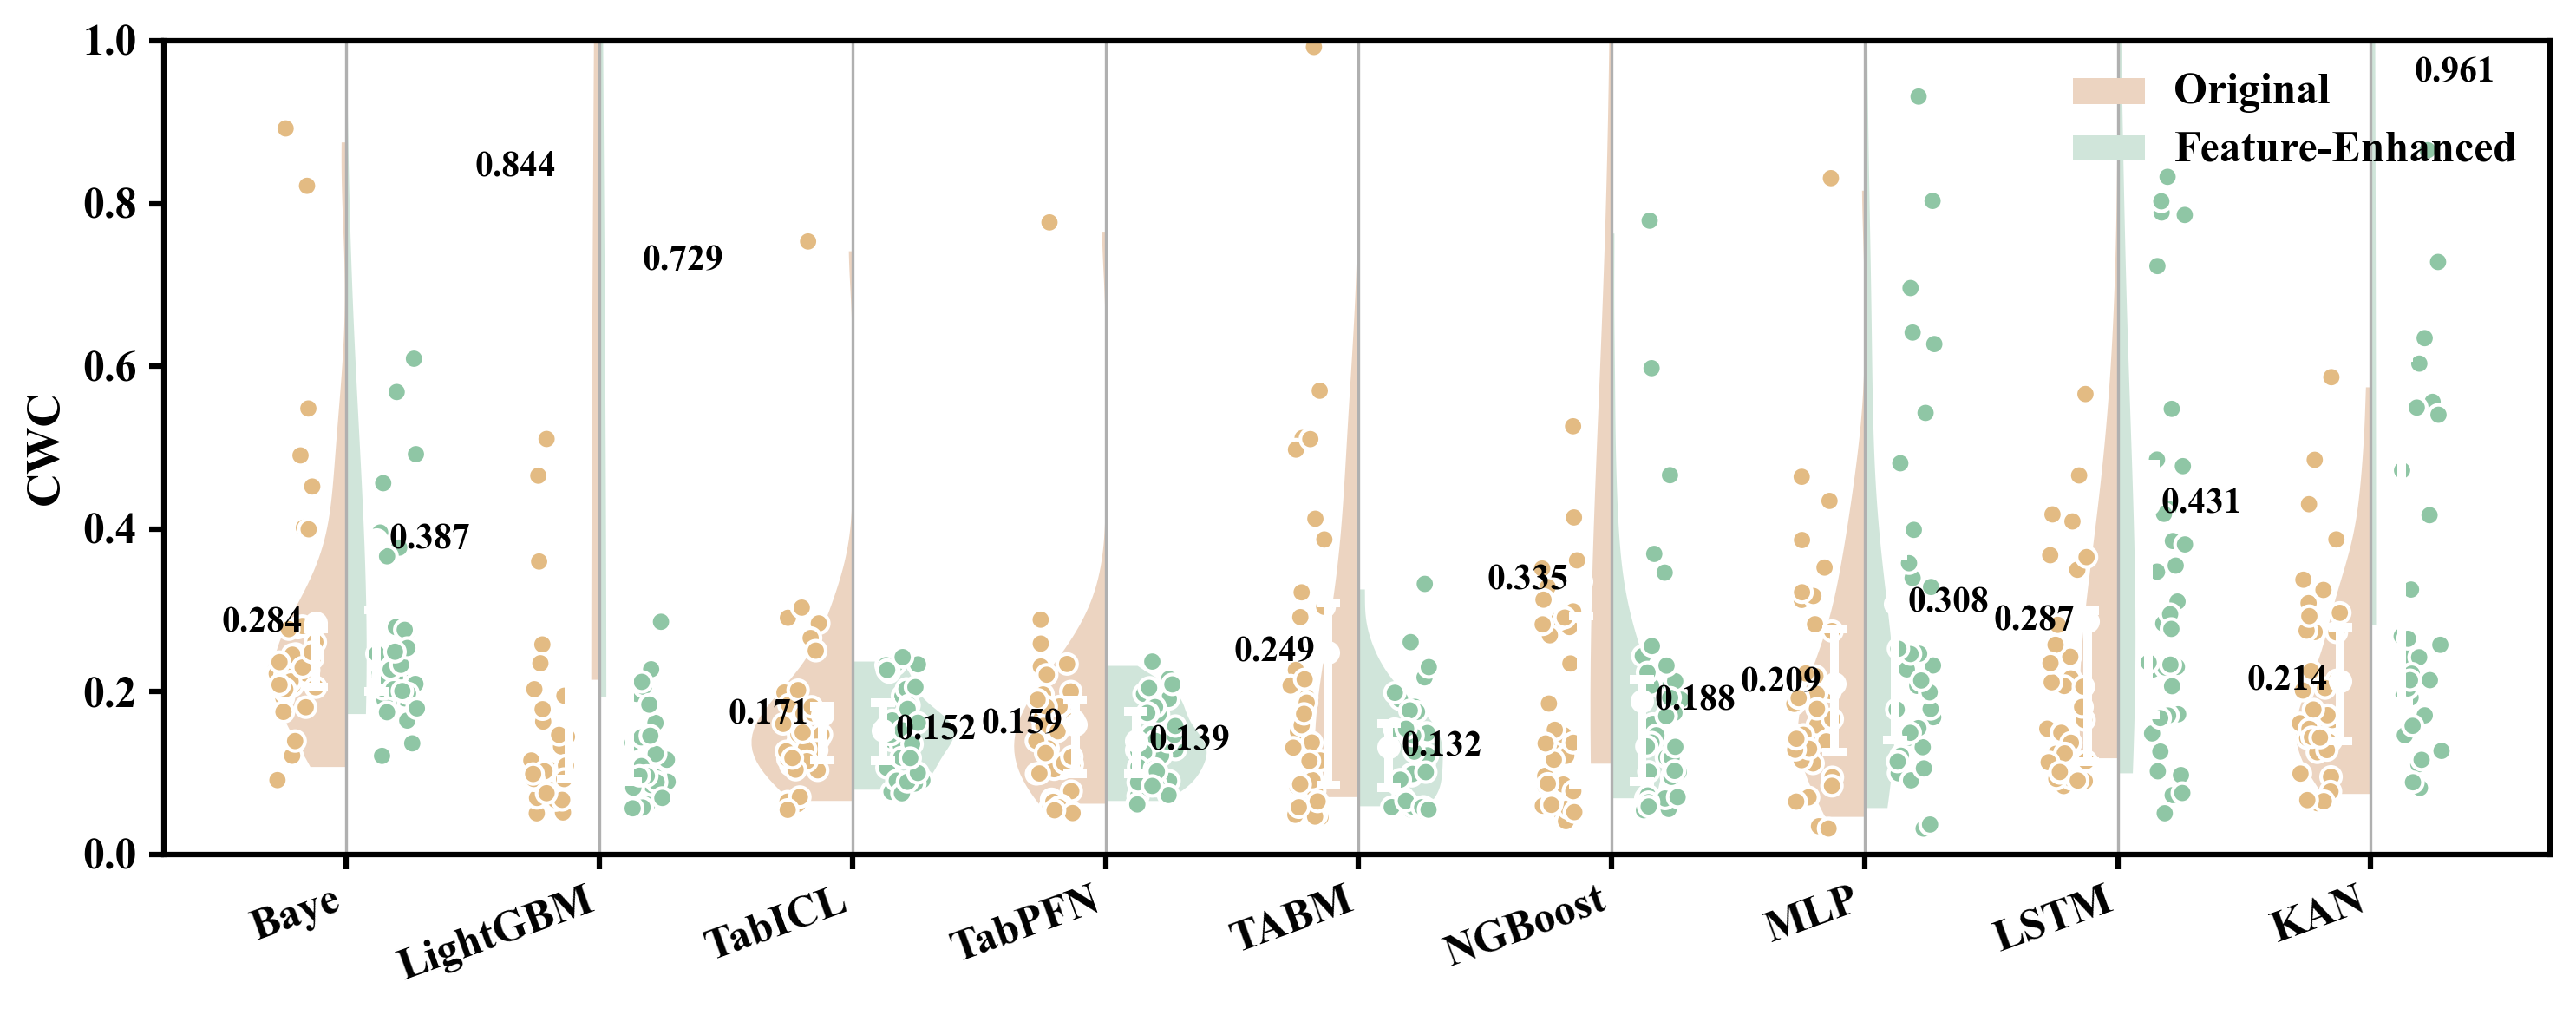

In [ ]:

import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ==============================
# Global style settings
# ==============================
matplotlib.rcParams["pdf.fonttype"] = 42
matplotlib.rcParams["ps.fonttype"] = 42
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.weight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["axes.titleweight"] = "bold"

# ==============================
# User settings
# ==============================
Original_FILE = "testday_100_noagu_predict_result1.xlsx"
Feature_Enhanced_FILE = "testday_100_agument_predict_result1.xlsx"   # Replace with your "Feature-Enhanced feature enhancement" file
METRIC_NAME = "CWC"   # Change to "CWC" or "IS" when needed
OUTPUT_DIR = r"figure_plot"
OUTPUT_NAME = f"100_day_test_bean_chart_{METRIC_NAME.lower()}"

PALETTE_VIOLIN = {
    "Feature-Enhanced": "#D0E5DA",
    "Original": "#ECD4C1",
}
PALETTE_SCATTER = {
    "Feature-Enhanced": "#8FC6A5",
    "Original": "#E3BB83",
}
# PALETTE_VIOLIN = {
#     "Feature-Enhanced": "#F9C4C4",
#     "Original": "#BCE0F4",
# }
# PALETTE_SCATTER = {
#     "Feature-Enhanced": "#E87C7C",
#     "Original": "#6AB5DE",
# }

# ==============================
# Helper functions
# ==============================
def get_metric_column_range(raw_df: pd.DataFrame, metric_name: str):
    """
    Find the start and end columns for a target metric block.
    The first row stores metric names, and the second row stores algorithm names.
    """
    metric_row = raw_df.iloc[0, :]
    metric_positions = [i for i, value in enumerate(metric_row) if str(value).strip() == metric_name]
    if not metric_positions:
        raise ValueError(f"Metric '{metric_name}' was not found in the first header row.")

    start_col = metric_positions[0]
    end_col = raw_df.shape[1] - 1

    for col in range(start_col + 1, raw_df.shape[1]):
        cell_value = raw_df.iat[0, col]
        if pd.notna(cell_value) and str(cell_value).strip() != "":
            end_col = col - 1
            break

    return start_col, end_col


def extract_metric_long_table(file_path: str, metric_name: str, condition_name: str):
    """
    Read one Excel file and convert the selected metric block to a long-format table.
    Expected file format:
    - Row 0: metric names
    - Row 1: algorithm names
    - Row 2: blank row
    - Remaining rows: station-level records
    """
    raw_df = pd.read_excel(file_path, header=None)

    start_col, end_col = get_metric_column_range(raw_df, metric_name)
    algorithm_names = raw_df.iloc[1, start_col:end_col + 1].tolist()

    station_mask = raw_df.iloc[:, 0].astype(str).str.startswith("PV_")
    data_df = raw_df.loc[station_mask, [0] + list(range(start_col, end_col + 1))].copy()
    data_df.columns = ["Station"] + algorithm_names

    long_df = data_df.melt(
        id_vars="Station",
        var_name="Algorithm",
        value_name="Value"
    )
    long_df["Value"] = pd.to_numeric(long_df["Value"], errors="coerce")
    long_df["Condition"] = condition_name
    long_df = long_df.dropna(subset=["Value"]).reset_index(drop=True)

    return long_df, algorithm_names


def add_summary_lines_and_text(ax, plot_df, algorithm_order, condition_order):
    """
    Draw the white IQR lines, mean points, and mean value labels on each side.
    """
    stats_df = (
        plot_df.groupby(["Algorithm", "Condition"])["Value"]
        .agg(
            mean="mean",
            q1=lambda x: np.percentile(x, 25),
            q3=lambda x: np.percentile(x, 75),
        )
        .reset_index()
    )

    offset_map = {"Original": -0.12, "Feature-Enhanced": 0.12}
    text_offset_map = {"Original": -0.05, "Feature-Enhanced": 0.05}
    cap_width = 0.03

    mean_lsit=[]
    for i, algorithm in enumerate(algorithm_order):
        for condition in condition_order:
            row = stats_df[
                (stats_df["Algorithm"] == algorithm) &
                (stats_df["Condition"] == condition)
            ].iloc[0]

            mean_val = row["mean"]
            q1_val = row["q1"]
            q3_val = row["q3"]
            mean_lsit.append(mean_val)
            x_pos = i + offset_map[condition]

            ax.plot([x_pos, x_pos], [q1_val, q3_val], color="white", lw=2.4, zorder=3)
            ax.plot([x_pos - cap_width, x_pos + cap_width], [q1_val, q1_val], color="white", lw=2.4, zorder=3)
            ax.plot([x_pos - cap_width, x_pos + cap_width], [q3_val, q3_val], color="white", lw=2.4, zorder=3)
            ax.plot(x_pos, mean_val, marker="o", color="white", markersize=5.5, zorder=4)

            ha = "right" if condition == "Original" else "left"
            ax.text(
                x_pos + text_offset_map[condition],
                mean_val,
                f"{mean_val:.3f}",
                ha=ha,
                va="center",
                fontsize=10,
                fontweight="bold",
                color="black",
                zorder=5
            )
    # print(mean_lsit)
    before_list = mean_lsit[0::2]

    # Extract after-enhancement values: index 1, 3, 5, ...
    after_list = mean_lsit[1::2]

    # Arrange into two rows and keep 4 decimal places
    mean_array = np.array([
        [round(x, 4) for x in before_list],
        [round(x, 4) for x in after_list]])
    print('Oringinal_and_augment')
    print(mean_array)


def plot_bean_chart(plot_df: pd.DataFrame, metric_name: str, output_dir: str, output_name: str):
    """
    Plot the split bean chart for one metric.
    """
    os.makedirs(output_dir, exist_ok=True)

    algorithm_order = plot_df["Algorithm"].drop_duplicates().tolist()
    condition_order = ["Original", "Feature-Enhanced"]

    fig, ax = plt.subplots(figsize=(10, 4), dpi=300)

    sns.violinplot(
        data=plot_df,
        x="Algorithm",
        y="Value",
        hue="Condition",
        hue_order=condition_order,
        split=True,
        inner=None,
        palette=PALETTE_VIOLIN,
        linewidth=0,
        cut=-0.2,
        saturation=1,
        ax=ax
    )

    sns.stripplot(
        data=plot_df,
        x="Algorithm",
        y="Value",
        hue="Condition",
        dodge=True,
        palette=PALETTE_SCATTER,
        alpha=1.0,
        size=5.5,
        jitter=0.16,
        zorder=2,
        order=algorithm_order,
        hue_order=condition_order,
        edgecolor="white",
        linewidth=1.0,
        ax=ax
    )

    add_summary_lines_and_text(ax, plot_df, algorithm_order, condition_order)
#   add_significance_labels(ax, plot_df, algorithm_order)


    handles, labels = ax.get_legend_handles_labels()
    legend = ax.legend(
            handles[:2],
            labels[:2],
            title="",
            loc="upper right",
            frameon=False)
    plt.setp(legend.get_texts(), fontweight="bold", fontsize=12)

    y_min = plot_df["Value"].min()
    y_max = plot_df["Value"].max()
    y_range = y_max - y_min
#     ax.set_ylim(y_min - 0.08 * y_range, y_max + 0.20 * y_range)
    ax.set_ylim(0, 1)

#     ax.set_title(f"{metric_name} Comparison Original and Feature-Enhanced Feature Enhancement", fontsize=16, fontweight="bold", pad=14)
    ax.set_xlabel("")
    ax.set_ylabel(metric_name, fontsize=13, fontweight="bold")

    ax.tick_params(
        axis="both",
        which="major",
        direction="out",
        length=4,
        width=1.5,
        labelsize=12
    )

    for tick in ax.get_xticklabels():
        tick.set_rotation(20)
        tick.set_ha("right")
        tick.set_fontweight("bold")

    for tick in ax.get_yticklabels():
        tick.set_fontweight("bold")

    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
        spine.set_color("black")

#     ax.grid(True)
    ax.xaxis.grid(True)
    ax.yaxis.grid(False)
    plt.tight_layout()

    png_path = os.path.join(output_dir, f"{output_name}.png")
    pdf_path = os.path.join(output_dir, f"{output_name}.pdf")
    plt.savefig(png_path, dpi=300, bbox_inches="tight")
    plt.savefig(pdf_path, bbox_inches="tight")
    plt.show()


# ==============================
# Main execution
# ==============================
if __name__ == "__main__":
    Original_long, algorithm_order_Original = extract_metric_long_table(
        file_path=Original_FILE,
        metric_name=METRIC_NAME,
        condition_name="Original"
    )

    Feature_Enhanced_long, algorithm_order_Feature_Enhanced = extract_metric_long_table(
        file_path=Feature_Enhanced_FILE,
        metric_name=METRIC_NAME,
        condition_name="Feature-Enhanced"
    )

#     if algorithm_order_Original != algorithm_order_after:
#         raise ValueError("The algorithm order in the two files is inconsistent.")

    plot_df = pd.concat([Original_long, Feature_Enhanced_long], ignore_index=True)

    plot_df["Algorithm"] = pd.Categorical(
        plot_df["Algorithm"],
        categories=algorithm_order_Original,
        ordered=True
    )

    plot_df["Condition"] = pd.Categorical(
        plot_df["Condition"],
        categories=["Original", "Feature-Enhanced"],
        ordered=True
    )

    plot_df = plot_df.sort_values(["Algorithm", "Condition", "Station"]).reset_index(drop=True)
    
    plot_bean_chart(
        plot_df=plot_df,
        metric_name=METRIC_NAME,
        output_dir=OUTPUT_DIR,
        output_name=OUTPUT_NAME
    )
